### 环境初始化

导入库

In [1]:
from typing import Sequence

from scipy.integrate import solve_ivp
from scipy.optimize import OptimizeResult
import matplotlib.pyplot as plt
import scienceplots

环境配置

In [2]:
plt.style.use("science")

工具函数

In [3]:
def equations(eqs: Sequence):
    return lambda *args: tuple(eq(*args) for eq in eqs)


def plot(sol: OptimizeResult, name: str, fmt: str = "pdf"):
    if len(sol.y) <= 1:
        plt.plot(sol.t, sol.y[0], label="N")
    else:
        for i, y in enumerate(sol.y):
            plt.plot(sol.t, y, label=f"$N_{i + 1}$")
        plt.legend()
    plt.xlabel("$t$")
    plt.ylabel("$N$")
    # plt.savefig(f"../thesis/figures/{name}.{fmt}", format=fmt)
    plt.show()

### Logistic 增长模型

$$
\frac{\mathrm{d} N}{\mathrm{d} t} = r N (1 - \frac{N}{K})
$$

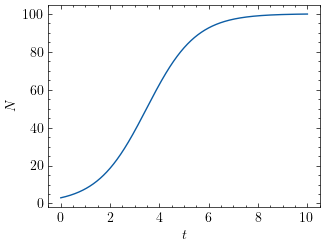

In [4]:
logistic = lambda t, N, r, K: r * N * (1 - N / K)
t_span = (0, 10)
y0 = [3]
r = 1
k = 100

sol = solve_ivp(logistic, t_span, y0, args=(r, k), max_step=0.01)
plot(sol, "logistic")

### Lotka-Volterra 竞争模型

$$
\frac{\mathrm{d} N_1}{\mathrm{d} t} = r_1 N_1 (1 - \frac{N_1}{K_1} - \alpha_{1,2} \frac{N_2}{K_1})
$$
$$
\frac{\mathrm{d} N_2}{\mathrm{d} t} = r_2 N_2 (1 - \frac{N_2}{K_2} - \alpha_{2,1} \frac{N_1}{K_2})
$$

$$
\vec{\alpha_i} := 
\begin{bmatrix}
    \alpha_{i,1} \\
    \alpha_{i,2} \\
    ... \\
    \alpha_{i,j}
\end{bmatrix}
$$
$$
\vec{N} := 
\begin{bmatrix}
    N_{1} \\
    N_{2} \\
    ... \\
    N_{i}
\end{bmatrix}
$$
$$
\frac{\mathrm{d} N_i}{\mathrm{d} t} = r_i N_i (1 - \frac{1}{K_i} \vec{\alpha_i} \cdot \vec{N})
$$

$$
\frac{\mathrm{d} N_i}{\mathrm{d} t} = r_i N_i (1 - \frac{1}{K_i} \sum_{j} \alpha_{i,j} N_j)
$$

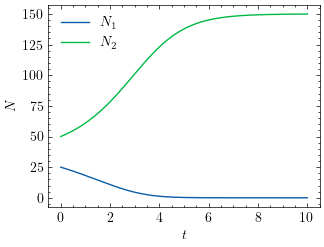

In [5]:
lvc = (
    lambda t, N, r, K, alpha: r[0] * N[0] * (1 - N[0] / K[0] - alpha[0] * N[1] / K[0]),
    lambda t, N, r, K, alpha: r[1] * N[1] * (1 - N[1] / K[1] - alpha[1] * N[0] / K[1]),
)  # TODO: vectorize

t_span = (0, 10)
y0 = [25, 50]
r = (1, 1)
k = (100, 150)
alpha = (2, 3)

sol = solve_ivp(equations(lvc), t_span, y0, args=(r, k, alpha), max_step=0.01)
plot(sol, "lotka-volterra-competition")

### Lotka-Volterra 捕食模型

$$
\frac{\mathrm{d} N_1}{\mathrm{d} t} = r_1 N_1 - \beta_{1,2} N_1 N_2
$$
$$
\frac{\mathrm{d} N_2}{\mathrm{d} t} = -r_2 N_2 + \beta_{2,1} N_1 N_2
$$

$$
\frac{\mathrm{d} N_i}{\mathrm{d} t} = N_i (r_i + \sum_{j} \beta_{i,j} N_j)
$$

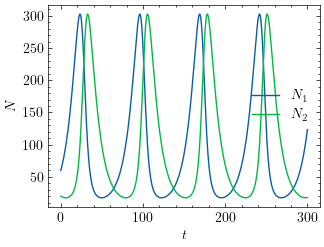

In [6]:
lvp = (
    lambda t, N, r, beta: r[0] * N[0] - beta[0] * N[0] * N[1],
    lambda t, N, r, beta: r[1] * N[1] + beta[1] * N[1] * N[0],
)  # TODO: vectorize

t_span = (0, 300)
y0 = [60, 20]
r = (0.1, -0.1)
beta = (0.001, 0.001)

sol = solve_ivp(equations(lvp), t_span, y0, args=(r, beta), max_step=0.01)
plot(sol, "lotka-volterra-predation")  # TODO: legend position

### 综合模型

$$
\frac{\mathrm{d} N_i}{\mathrm{d} t} = N_i (1 - \frac{1}{K_i} \sum_{j} \alpha_{i,j} N_j) (r_i + \sum_{j} \beta_{i,j} N_j) + L(t)
$$

In [7]:
# TODO: general model